In [93]:
from typing import Any, Dict

import matplotlib.pyplot as plt
import numpy as np
import torch

In [94]:
from solver.optimizer import optimize_camera_trajectory

In [95]:
import math
def make_subject_tracks(
        total_frames=1200, image_w=1920, image_h=1080):
    tracks = {}
    A = []
    for f in range(total_frames):
        u = f / (total_frames - 1)
        cx = -2.0 + 4.0*u
        cz =  0.5 + 1.0*u
        cy =  1.6  
        h = 320 + int(80*math.sin(2*math.pi*u))
        w = int(h * 0.45)
        px = int(image_w*0.5 + 250*(cx/4.0))
        py = int(image_h*0.55 - 60*(cz/2.0))
        bbox = {"x1":1, "y1": 1, "x2": 1, "y2":1}
        A.append({"bbox": bbox, "C0": [0 , 0 , 0]})
    tracks["C0"] = A
    B = []
    for f in range(total_frames):
        u = f / (total_frames - 1)
        cx = 1.0
        cz = 2.5
        cy = 1.6 + 0.05*math.sin(4*math.pi*u)
        h = 220
        w = int(h * 0.45)
        px = int(image_w*0.65)
        py = int(image_h*0.58)
        bbox = {"x1": px-w//2, "y1": py-h, "x2": px+w//2, "y2": py}
        B.append({"bbox": bbox, "C0": [cx, cy, cz]})
    tracks["B"] = B

    return tracks

In [96]:
start_pose = {
    "kind": "point",
    "t": 0,
    "position": [0.0, 1.6, -6.0],
    "quaternion": [1.0, 0.0, 0.0, 0.0],
    "losses": []
}

In [97]:
def build_subject_centers(subject_tracks, total_frames, device):
    centers = {}

    for sid, track in subject_tracks.items():
        c = []
        for f in range(total_frames):
            c.append(track[f]["C0"])
        centers[sid] = torch.tensor(c, dtype=torch.float32, device=device)

    return centers

In [118]:
subject_tracks = make_subject_tracks()
subject_centers = build_subject_centers(subject_tracks , 1200 , "cpu")

In [99]:
import numpy as np
import matplotlib.pyplot as plt

def _to_numpy(a):
    if a is None:
        return None
    if hasattr(a, "detach"):  # torch tensor
        return a.detach().cpu().numpy()
    return np.asarray(a)

def _q_normalize_np(q, eps=1e-8):
    q = np.asarray(q, dtype=np.float64)
    n = np.linalg.norm(q, axis=-1, keepdims=True)
    return q / (n + eps)

def _q_conj_np(q):
    q = np.asarray(q)
    out = q.copy()
    out[..., 1:] *= -1.0
    return out

def _q_mul_np(a, b):
    """
    Quaternion multiply for arrays (...,4), format [w,x,y,z]
    """
    aw, ax, ay, az = np.moveaxis(a, -1, 0)
    bw, bx, by, bz = np.moveaxis(b, -1, 0)

    w = aw*bw - ax*bx - ay*by - az*bz
    x = aw*bx + ax*bw + ay*bz - az*by
    y = aw*by - ax*bz + ay*bw + az*bx
    z = aw*bz + ax*by - ay*bx + az*bw
    return np.stack([w, x, y, z], axis=-1)

def _q_rotate_np(q, v):
    """
    Rotate vector(s) v by quaternion(s) q.
    q: (N,4) or (4,)
    v: (3,) or (N,3)
    Returns rotated vector(s) shape matching broadcast.
    """
    q = _q_normalize_np(q)

    v = np.asarray(v, dtype=np.float64)
    if v.ndim == 1:
        # broadcast one vector to q batch if needed
        if q.ndim == 2:
            v = np.tile(v[None, :], (q.shape[0], 1))

    zeros = np.zeros(v.shape[:-1] + (1,), dtype=v.dtype)
    vq = np.concatenate([zeros, v], axis=-1)

    return _q_mul_np(_q_mul_np(q, vq), _q_conj_np(q))[..., 1:]

def plot_points_trajectory(
    P,
    Q=None,
    fps=30,
    ax=None,
    title="Camera trajectory",
    arrow_every=None,
    arrow_len=None,
    forward_local=(0, 0, 1),  # if your camera forward is -Z, use (0,0,-1)
):
    """
    P: torch.Tensor or np.ndarray of shape (N,3)
    Q: torch.Tensor or np.ndarray of shape (N,4), quaternion [w,x,y,z] (optional)
    fps: frames per second (used for start/end time labels)

    Plot convention:
      - horizontal axes: x and z
      - vertical axis: y
    (implemented by plotting as Xplot=x, Yplot=z, Zplot=y)
    """
    # --- convert to numpy ---
    Pn = _to_numpy(P).astype(np.float64)
    Qn = _to_numpy(Q).astype(np.float64) if Q is not None else None

    if Pn.ndim != 2 or Pn.shape[1] != 3:
        raise ValueError(f"P must have shape (N,3), got {Pn.shape}")

    N = len(Pn)
    if N == 0:
        raise ValueError("P is empty")

    if Qn is not None:
        if Qn.ndim != 2 or Qn.shape[1] != 4:
            raise ValueError(f"Q must have shape (N,4), got {Qn.shape}")
        if len(Qn) != N:
            raise ValueError(f"P and Q must have same length, got {len(Pn)} and {len(Qn)}")

    # World coords
    x, y, z = Pn[:, 0], Pn[:, 1], Pn[:, 2]

    # --- remap for plotting so y is vertical ---
    # Matplotlib 3D uses z-axis as vertical on screen, so we map:
    # world (x, y, z) -> plot (X=x, Y=z, Z=y)
    Xp = x
    Yp = z
    Zp = y

    # --- axes ---
    created_ax = False
    if ax is None:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection="3d")
        created_ax = True

    # --- main trajectory line ---
    ax.plot(Xp, Yp, Zp, marker="o", markersize=3, linewidth=1)

    # --- START / END markers ---
    ax.scatter([Xp[0]],  [Yp[0]],  [Zp[0]],  s=140, marker="*", label="Start")
    ax.scatter([Xp[-1]], [Yp[-1]], [Zp[-1]], s=120, marker="X", label="End")

    # --- START / END labels (frame + time) ---
    t0_sec = 0.0
    t1_sec = (N - 1) / float(fps)
    ax.text(Xp[0],  Yp[0],  Zp[0],  f"  START\n  f=0, t={t0_sec:.2f}s")
    ax.text(Xp[-1], Yp[-1], Zp[-1], f"  END\n  f={N-1}, t={t1_sec:.2f}s")

    # --- orientation arrows from Q (camera forward direction) ---
    if Qn is not None:
        # Choose how densely to draw arrows
        if arrow_every is None:
            arrow_every = max(1, N // 20)  # ~20 arrows max by default

        idx = np.arange(0, N, arrow_every, dtype=int)
        if idx[-1] != N - 1:
            idx = np.concatenate([idx, [N - 1]])

        Qs = _q_normalize_np(Qn[idx])

        # Forward direction in world coords
        fwd = _q_rotate_np(Qs, np.array(forward_local, dtype=np.float64))
        # normalize arrow directions
        fwd_norm = np.linalg.norm(fwd, axis=-1, keepdims=True)
        fwd = fwd / (fwd_norm + 1e-8)

        # Auto arrow length based on trajectory size
        if arrow_len is None:
            span = np.ptp(Pn, axis=0)  # world spans in x,y,z
            diag = np.linalg.norm(span)
            arrow_len = 0.06 * diag if diag > 1e-8 else 0.2

        # Scale arrows
        d_world = fwd * float(arrow_len)

        # Remap arrow directions to plot coords: (dx,dy,dz) = (x,z,y)
        dXp = d_world[:, 0]
        dYp = d_world[:, 2]
        dZp = d_world[:, 1]

        # Arrow origins
        PX = Xp[idx]
        PY = Yp[idx]
        PZ = Zp[idx]

        ax.quiver(
            PX, PY, PZ,
            dXp, dYp, dZp,
            length=1.0,          # vectors already scaled
            normalize=False,
            arrow_length_ratio=0.25
        )

    # --- cosmetics ---
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("z")
    ax.set_zlabel("y (vertical)")
    ax.legend()

    # Better aspect ratio (so geometry is not too distorted)
    xr = np.ptp(Xp)
    yr = np.ptp(Yp)
    zr = np.ptp(Zp)
    xr = xr if xr > 1e-6 else 1.0
    yr = yr if yr > 1e-6 else 1.0
    zr = zr if zr > 1e-6 else 1.0
    try:
        ax.set_box_aspect((xr, yr, zr))
    except Exception:
        pass  # older matplotlib may not support this

    if created_ax:
        plt.show()

    return ax

In [100]:

start_pose = {
    "kind": "point",
    "t": 0,
    "position": [0.0, 1.6, -6.0],
    "quaternion": [1.0, 0.0, 0.0, 0.0],
    "losses": []
}
subject_centers = {
    "C0": torch.tensor([[0.0, 1.6, 0.0]] * 120, dtype=torch.float32, device="cpu")
}
constraints = [
    start_pose,
    
    {
        "kind": "interval",
        "t0": 0, "t1":  1200,
        "losses": [
            {"type": "truckRightMovement", "distance"  :3}
        ]
    }
]


out = optimize_camera_trajectory(constraints, duration_seconds=40, trajectory_mode="matrix", spline_degree=3, subject_tracks=subject_tracks, subject_centers=subject_centers)

In [101]:
P = out["P"]
Q = out["Q"]

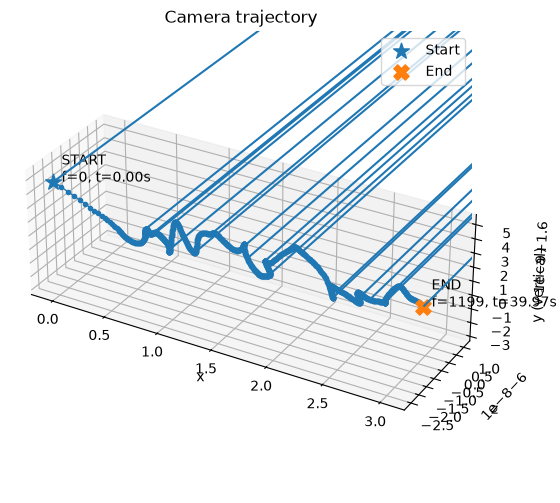

<Axes3D: title={'center': 'Camera trajectory'}, xlabel='x', ylabel='z', zlabel='y (vertical)'>

In [102]:
plot_points_trajectory(P, Q)

In [103]:

start_pose = {
    "kind": "point",
    "t": 0,
    "position": [4, 0, 0],
    "quaternion": [1.0, 0.0, 0.0, 0.0],
    "losses": []
}
subject_centers = {
    "C0": torch.tensor([[0.0, 0, 0.0]] * 1200, dtype=torch.float32, device="cpu")
}
constraints = [
    start_pose,
    
    {
        "kind": "interval",
        "t0": 0, "t1":  1200,
        "k": 15,
        "losses": [
            {"type": "arcMovement","subjectId": "C0", "angleDeg": 360.0 , "radius" : 4}
        ]
    }
    # {
    #     "kind": "interval",
    #     "t0": 0, "t1":  1200,
    #     "k": 15,
    #     "losses": [
    #         {"type": "staticMovement"}
    #     ]
    # }
]

out = optimize_camera_trajectory(constraints, duration_seconds=40, trajectory_mode="matrix", spline_degree=12, subject_tracks=subject_tracks, subject_centers=subject_centers , loss_threshold=1)

Iter  100 | Loss 1808.918988 | mode=matrix
Iter  200 | Loss 255.866722 | mode=matrix
Iter  300 | Loss 90.406456 | mode=matrix
Iter  400 | Loss 71.204857 | mode=matrix
Iter  500 | Loss 63.093834 | mode=matrix
Iter  600 | Loss 57.246507 | mode=matrix
Iter  700 | Loss 52.462782 | mode=matrix
Iter  800 | Loss 48.487367 | mode=matrix
Iter  900 | Loss 45.890485 | mode=matrix
Iter 1000 | Loss 43.005043 | mode=matrix
Iter 1100 | Loss 40.961316 | mode=matrix
Iter 1200 | Loss 39.388662 | mode=matrix
Iter 1300 | Loss 50.129124 | mode=matrix
Iter 1400 | Loss 46.823725 | mode=matrix
Iter 1500 | Loss 42.387892 | mode=matrix
Iter 1600 | Loss 39.162852 | mode=matrix
Iter 1700 | Loss 36.784899 | mode=matrix
Iter 1800 | Loss 36.004665 | mode=matrix
Iter 1900 | Loss 34.422462 | mode=matrix
Iter 2000 | Loss 33.717429 | mode=matrix


In [104]:

start_pose = {
    "kind": "point",
    "t": 0,
    "position": [0.0, 0, 0],
    "quaternion": [1.0, 0.0, 0.0, 0.0],
    "losses": []
}
subject_centers = {
    "C0": torch.tensor([[0.0, 1.6, 0.0]] * 1200, dtype=torch.float32, device="cpu")
}
constraints = [
    start_pose,
    
    {
        "kind": "interval",
        "t0": 0, "t1":  1200,
        "k": 15,
        "losses": [
            {"type": "arcMovement","subjectId": "C0", "angleDeg": 540.0 , "radius" : 4}
        ]
    }
]

out = optimize_camera_trajectory(constraints, duration_seconds=40, trajectory_mode="matrix", spline_degree=9, subject_tracks=subject_tracks, subject_centers=subject_centers , loss_threshold=1)
P = out["P"]
Q = out["Q"]

Iter  100 | Loss 5645.920019 | mode=matrix
Iter  200 | Loss 3298.664771 | mode=matrix
Iter  300 | Loss 2645.734471 | mode=matrix
Iter  400 | Loss 1574.253580 | mode=matrix
Iter  500 | Loss 1203.259286 | mode=matrix
Iter  600 | Loss 1109.482813 | mode=matrix
Iter  700 | Loss 1062.608085 | mode=matrix
Iter  800 | Loss 964.348962 | mode=matrix
Iter  900 | Loss 904.910345 | mode=matrix
Iter 1000 | Loss 860.122676 | mode=matrix
Iter 1100 | Loss 824.317770 | mode=matrix
Iter 1200 | Loss 810.688271 | mode=matrix
Iter 1300 | Loss 757.335294 | mode=matrix
Iter 1400 | Loss 709.503803 | mode=matrix
Iter 1500 | Loss 661.716444 | mode=matrix
Iter 1600 | Loss 636.565616 | mode=matrix
Iter 1700 | Loss 581.595817 | mode=matrix
Iter 1800 | Loss 537.611160 | mode=matrix
Iter 1900 | Loss 500.043574 | mode=matrix
Iter 2000 | Loss 465.854629 | mode=matrix


In [105]:
import torch
subject_centers = {
    "C0": torch.tensor([[0.0, 1.6, 0.0]] * 120, dtype=torch.float32, device="cpu")
}
constraints = [
    start_pose,
    # {
    #     "kind": "interval",
    #     "t0": 0, "t1": 1200,
    #     "k": 400,
    #     "losses": [
    #         {"type": "arcMovement","subjectId": "C0", "angleDeg": 180.0 , "radius" : 4},
    #         #{"type": "truckMovement",  "distance": 5.0},
    #     ]
    # },
    {
        "kind": "interval",
        "t0": 0, "t1":  500,
        "k": 20,
        "losses": [
            {"type": "pedestalUpMovement", "distance"  :3}
        ]
    },

    {
        "kind": "interval",
        "t0": 500, "t1": 700,
        "k": 20,
        "losses": [
            {"type": "truckLeftMovement", "distance" : 4}
        ]
    },
    {
        "kind": "interval",
        "t0": 700, "t1": 1200,
        "k": 20,
        "losses": [
            {"type": "tiltMovement",  "angleDeg": 90.0}
        ]
    }
]

In [106]:
out = optimize_camera_trajectory(constraints, duration_seconds=40, trajectory_mode="matrix", spline_degree=2, subject_tracks=subject_tracks, subject_centers=subject_centers , loss_threshold=300)

Iter  100 | Loss 430.608559 | mode=matrix


In [107]:
P = out["P"]
Q = out["Q"]
#t = out["t"]

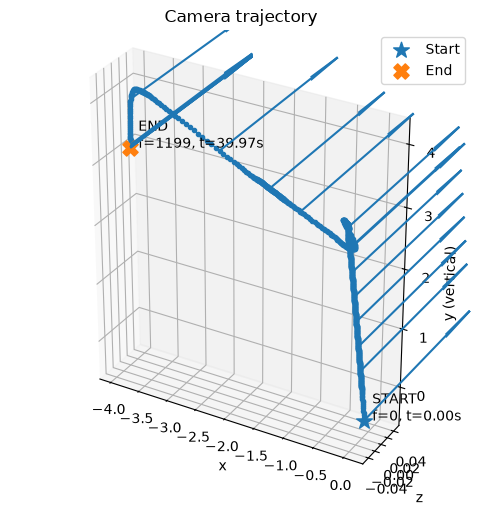

<Axes3D: title={'center': 'Camera trajectory'}, xlabel='x', ylabel='z', zlabel='y (vertical)'>

In [108]:
# degree = 15

#arc , pedestal , truck
plot_points_trajectory(P, Q )

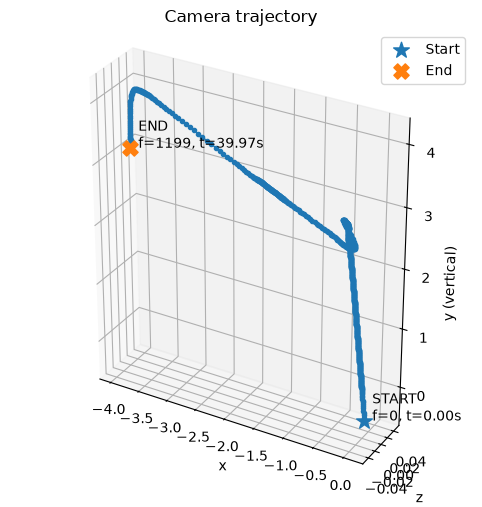

<Axes3D: title={'center': 'Camera trajectory'}, xlabel='x', ylabel='z', zlabel='y (vertical)'>

In [109]:
P = out["P"]
Q = out["Q"]
#t = out["t"]
plot_points_trajectory(P , fps = 30)

In [110]:
   # Example usage demonstrating a simple constraint setup
    # Define a starting pose constraint
start_pose: Dict[str, Any] = {
        "kind": "point",
        "t": 0,
        "position": [0.0, 10, 0.0],
        "quaternion": [1.0, 0.0, 0.0, 0.0],
        "losses": [],
    }

    # Define an interval constraint for an arc around subject C0
interval: Dict[str, Any] =     {
        "kind": "interval",
        "t0": 0, "t1":  1200,
        "k": 15,
        "losses": [
            {"type": "pedestalUpMovement" , "distance"  :3}
        ]
    }

    # Build a dummy subject track for C0
total_duration = 2.0  # seconds
fps = 30
total_frames = int(round(total_duration * fps))
subject_tracks = {
    "C0": [
        {"bbox": {"x1": 0, "y1": 0, "x2": 0, "y2": 0}, "center3d": [0.0,0.0, 0.0]}
        for _ in range(total_frames)
    ]
 }

result = optimize_camera_trajectory(
        constraints=[start_pose, interval],
        duration_seconds=total_duration,
        frames_per_second=fps,
        image_width=1920,
        image_height=1080,
        subject_tracks=subject_tracks,
        device="cpu",
        learning_rate=1e-2,
        max_iterations=5000,
        loss_threshold=0.01,
        spline_degree=3,
        initialization_mode="constraint",
    )
    # Print the final loss and number of iterations
print(f"Optimized trajectory with {len(result['history'])} iterations; final loss = {result['history'][-1]:.6f}")

Iter  100 | Loss 5.084665 | mode=matrix
Iter  200 | Loss 5.084637 | mode=matrix
Iter  300 | Loss 5.084637 | mode=matrix
Iter  400 | Loss 5.084637 | mode=matrix
Iter  500 | Loss 5.084637 | mode=matrix
Iter  600 | Loss 5.084637 | mode=matrix
Iter  700 | Loss 5.084637 | mode=matrix
Iter  800 | Loss 5.084637 | mode=matrix
Iter  900 | Loss 5.084637 | mode=matrix
Iter 1000 | Loss 5.084637 | mode=matrix
Iter 1100 | Loss 5.084637 | mode=matrix
Iter 1200 | Loss 5.084637 | mode=matrix
Iter 1300 | Loss 5.084637 | mode=matrix
Iter 1400 | Loss 5.084637 | mode=matrix
Iter 1500 | Loss 5.084637 | mode=matrix
Iter 1600 | Loss 5.084637 | mode=matrix
Iter 1700 | Loss 5.084637 | mode=matrix
Iter 1800 | Loss 5.084637 | mode=matrix
Iter 1900 | Loss 5.084637 | mode=matrix
Iter 2000 | Loss 5.084637 | mode=matrix
Iter 2100 | Loss 5.084688 | mode=matrix
Iter 2200 | Loss 5.084637 | mode=matrix
Iter 2300 | Loss 5.084637 | mode=matrix
Iter 2400 | Loss 5.084637 | mode=matrix
Iter 2500 | Loss 5.084637 | mode=matrix


In [111]:
P = result['P']
Q = result['Q']

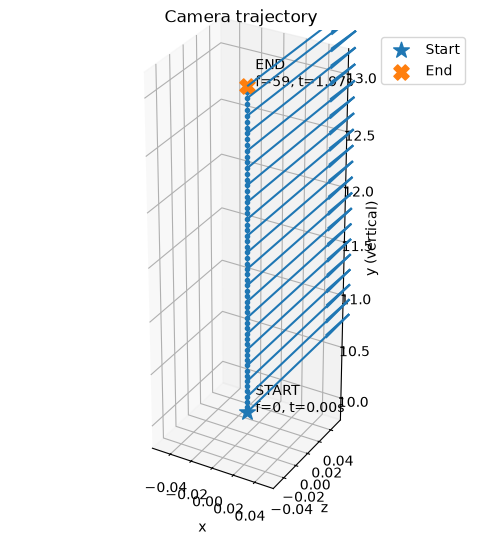

<Axes3D: title={'center': 'Camera trajectory'}, xlabel='x', ylabel='z', zlabel='y (vertical)'>

In [112]:
plot_points_trajectory(P , Q)

In [113]:

start_pose = {
    "kind": "point",
    "t": 0,
    "position": [0.0, 1.6, -6.0],
    "quaternion": [1.0, 0.0, 0.0, 0.0],
    "losses": []
}
subject_centers = {
    "C0": torch.tensor([[0.0, 1.6, 0.0]] * 120, dtype=torch.float32, device="cpu")
}
constraints = [
    start_pose,
    
    {
        "kind": "interval",
        "t0": 0, "t1":  1200,
        "k": 15,
        "losses": [
            {"type": "pedestalUpMovement" , "distance"  :3}
        ]
    }
]


out = optimize_camera_trajectory(constraints, duration_seconds=40, trajectory_mode="interpolation", spline_degree=3, subject_tracks=subject_tracks, subject_centers=subject_centers, loss_threshold=1e-4)

Iter  100 | Loss 0.250700 | mode=interpolation
Iter  200 | Loss 0.250653 | mode=interpolation
Iter  300 | Loss 0.250653 | mode=interpolation
Iter  400 | Loss 0.250653 | mode=interpolation
Iter  500 | Loss 0.250652 | mode=interpolation
Iter  600 | Loss 0.250652 | mode=interpolation
Iter  700 | Loss 0.250652 | mode=interpolation
Iter  800 | Loss 0.250651 | mode=interpolation
Iter  900 | Loss 0.250651 | mode=interpolation
Iter 1000 | Loss 0.250651 | mode=interpolation
Iter 1100 | Loss 0.250651 | mode=interpolation
Iter 1200 | Loss 0.250651 | mode=interpolation
Iter 1300 | Loss 0.250650 | mode=interpolation
Iter 1400 | Loss 0.568820 | mode=interpolation
Iter 1500 | Loss 0.250817 | mode=interpolation
Iter 1600 | Loss 0.250796 | mode=interpolation
Iter 1700 | Loss 0.250783 | mode=interpolation
Iter 1800 | Loss 0.250774 | mode=interpolation
Iter 1900 | Loss 0.250767 | mode=interpolation
Iter 2000 | Loss 0.250761 | mode=interpolation


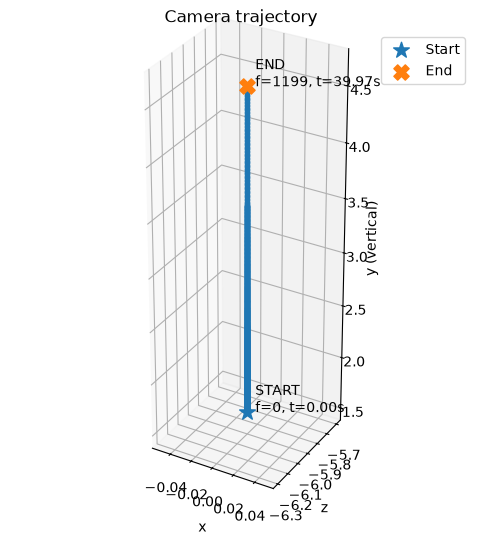

<Axes3D: title={'center': 'Camera trajectory'}, xlabel='x', ylabel='z', zlabel='y (vertical)'>

In [114]:

P = out["P"]
Q = out["Q"]

plot_points_trajectory(P)

In [115]:

start_pose = {
    "kind": "point",
    "t": 0,
    "position": [0.0, 1.6, -6.0],
    "quaternion": [1.0, 0.0, 0.0, 0.0],
    "losses": []
}
subject_centers = {
    "C0": torch.tensor([[0.0, 1.6, 0.0]] * 120, dtype=torch.float32, device="cpu")
}
constraints = [
    start_pose,
    
    {
        "kind": "interval",
        "t0": 0, "t1":  1200,
        "k": 15,
        "losses": [
            {"type": "TruckRightMovement" , "distance"  :3}
        ]
    }
]


out = optimize_camera_trajectory(constraints, duration_seconds=40, trajectory_mode="interpolation", spline_degree=3, subject_tracks=subject_tracks, subject_centers=subject_centers, loss_threshold=1e-4)

Iter  100 | Loss 0.010043 | mode=interpolation
Iter  200 | Loss 0.010041 | mode=interpolation
Iter  300 | Loss 0.010040 | mode=interpolation
Iter  400 | Loss 0.010085 | mode=interpolation
Iter  500 | Loss 0.010047 | mode=interpolation
Iter  600 | Loss 0.010137 | mode=interpolation
Iter  700 | Loss 0.010061 | mode=interpolation
Iter  800 | Loss 0.010058 | mode=interpolation
Iter  900 | Loss 0.010085 | mode=interpolation
Iter 1000 | Loss 0.010056 | mode=interpolation
Iter 1100 | Loss 0.010100 | mode=interpolation
Iter 1200 | Loss 0.010278 | mode=interpolation
Iter 1300 | Loss 0.010126 | mode=interpolation
Iter 1400 | Loss 0.010516 | mode=interpolation
Iter 1500 | Loss 0.010063 | mode=interpolation
Iter 1600 | Loss 0.010151 | mode=interpolation
Iter 1700 | Loss 0.010268 | mode=interpolation
Iter 1800 | Loss 0.010076 | mode=interpolation
Iter 1900 | Loss 0.010073 | mode=interpolation
Iter 2000 | Loss 0.010461 | mode=interpolation


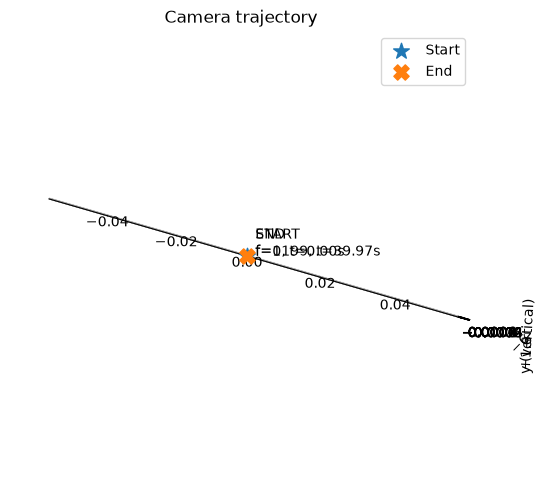

<Axes3D: title={'center': 'Camera trajectory'}, xlabel='x', ylabel='z', zlabel='y (vertical)'>

In [116]:

P = out["P"]
Q = out["Q"]

plot_points_trajectory(P)

In [129]:

start_pose = {
    "kind": "point",
    "t": 0,
    "position": [0.0, 1.6, -6.0],
    "quaternion": [1.0, 0.0, 0.0, 0.0],
    "losses": []
}
subject_centers = {
    "C0": torch.tensor([[0.0, 1.6, 0.0]] * 120, dtype=torch.float32, device="cpu")
}
constraints = [
    start_pose,
    
    {
        "kind": "interval",
        "t0": 0, "t1":  200,
        "k": 15,
        "losses": [
            {"type": "TruckRightMovement" , "distance"  :3}
        ]
    },
    {
        "kind": "interval",
        "t0": 150, "t1":  600,
        "k": 15,
        "losses": [
            {"type": "PedestalUpMovement" , "distance"  :3}
        ]
    },
    {
        "kind": "interval",
        "t0": 600,
        "t1": 1200,
        "k": 60,
        "losses": [
            {"type": "arcMovement", "subjectId": "C0", "angleDeg": 360.0, "radius": 3.0},
        ],
    }
]


out = optimize_camera_trajectory(constraints, duration_seconds=2.0, trajectory_mode="matrix", spline_degree=12, subject_tracks=subject_tracks, subject_centers=subject_centers, loss_threshold=1e-4, max_iterations=5000)

Iter  100 | Loss 15.359061 | mode=matrix
Iter  200 | Loss 6.029772 | mode=matrix
Iter  300 | Loss 3.425709 | mode=matrix
Iter  400 | Loss 2.599923 | mode=matrix
Iter  500 | Loss 1.805989 | mode=matrix
Iter  600 | Loss 1.003614 | mode=matrix
Iter  700 | Loss 0.331612 | mode=matrix
Iter  800 | Loss 0.083868 | mode=matrix
Iter  900 | Loss 0.068650 | mode=matrix
Iter 1000 | Loss 0.051824 | mode=matrix
Iter 1100 | Loss 0.055551 | mode=matrix
Iter 1200 | Loss 0.049990 | mode=matrix
Iter 1300 | Loss 0.046581 | mode=matrix
Iter 1400 | Loss 0.038953 | mode=matrix
Iter 1500 | Loss 0.041183 | mode=matrix
Iter 1600 | Loss 0.039877 | mode=matrix
Iter 1700 | Loss 0.038678 | mode=matrix
Iter 1800 | Loss 0.037631 | mode=matrix
Iter 1900 | Loss 0.042619 | mode=matrix
Iter 2000 | Loss 0.040532 | mode=matrix
Iter 2100 | Loss 0.037214 | mode=matrix
Iter 2200 | Loss 0.044243 | mode=matrix
Iter 2300 | Loss 0.039699 | mode=matrix
Iter 2400 | Loss 0.038708 | mode=matrix
Iter 2500 | Loss 0.036792 | mode=matrix

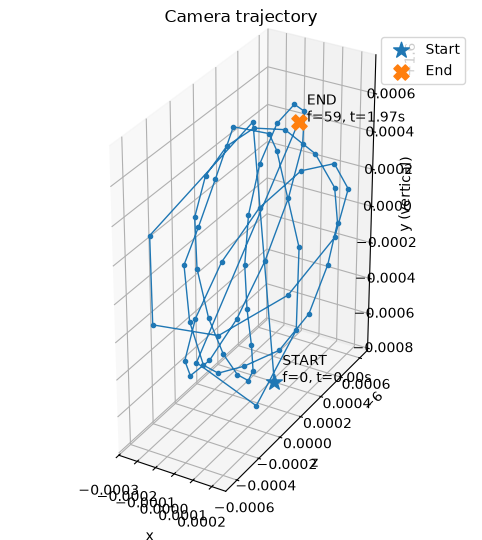

<Axes3D: title={'center': 'Camera trajectory'}, xlabel='x', ylabel='z', zlabel='y (vertical)'>

In [130]:

P = out["P"]
Q = out["Q"]

plot_points_trajectory(P)